In [ ]:
# 1. Installation des dépendances
!pip install git+https://github.com/cvg/LightGlue.git
!pip install torch torchvision numpy opencv-python matplotlib

# 2. Imports
import torch
import numpy as np
import requests
from PIL import Image
from io import BytesIO
from lightglue import LightGlue, SuperPoint
from lightglue.utils import rbd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Environnement prêt sur : {device}")

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-hzxrjnk2
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-hzxrjnk2
  Resolved https://github.com/cvg/LightGlue.git to commit 746fac2c042e05d1865315b1413419f1c1e7ba55
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.0 MB/s eta 0:00:00
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40026 sha256=0dbe997085de1c800863da25618a7f2b54238192e736b765a35d7f0239bf264f
  Stored in directory: /tmp/pip-ephem-wheel-cache-8i5hdv6o/wheels/dc/16/88/ad4ddb490c3a6ff37eeface44b776cb588b19e169210e0fbf1
Successfully built lightglue
✅ Environnement prêt sur : cuda


In [ ]:
# Chargement de l'extracteur SuperPoint (Original)
extractor = SuperPoint(max_num_keypoints=1024).eval().to(device)

# Chargement du Matcher LightGlue (Original)
# flash_attention=False pour mieux voir les opérations dans le profiler au début
matcher = LightGlue(features='superpoint', flash=False).eval().to(device)

print(" Modèles originaux chargés (SuperPoint + LightGlue).")

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 71.7MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 232MB/s]


✅ Modèles originaux chargés (SuperPoint + LightGlue).


In [ ]:
def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('L') # Noir et blanc
    img = img.resize((640, 480)) # Une résolution standard type VGA
    tensor = torch.from_numpy(np.array(img)).float()[None, None] / 255.0
    return tensor.to(device)

url1 = "https://raw.githubusercontent.com/cvg/LightGlue/main/assets/sacre_coeur1.jpg"
url2 = "https://raw.githubusercontent.com/cvg/LightGlue/main/assets/sacre_coeur2.jpg"

img0 = load_image_from_url(url1)
img1 = load_image_from_url(url2)

with torch.no_grad():
    feats0 = extractor({'image': img0})
    feats1 = extractor({'image': img1})

print(f" Points extraits : {feats0['keypoints'].shape[1]} points sur l'image 0.")

✅ Points extraits : 993 points sur l'image 0.


In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity


for _ in range(5):
    matcher({'image0': feats0, 'image1': feats1})

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("model_inference"):
        matcher({'image0': feats0, 'image1': feats1})

print("\n --- RÉSULTATS DU PROFILING (Top 15 Opérations les plus lourdes) ---")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))

🕵️‍♂️ Lancement du Profiling sur LightGlue...

📊 --- RÉSULTATS DU PROFILING (Top 15 Opérations les plus lourdes) ---
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference         0.00%       0.000us         0.00%       0.000us       0.000us      56.650ms       167.84%      56.650ms      56.650ms             1  
                                        model_inference        29.44%      17.971ms       

In [ ]:
import time

# 1. Chargement des deux versions
matcher_deep = LightGlue(features='superpoint', flash=False).eval().to(device)
matcher_shallow = LightGlue(features='superpoint', flash=False, depth=4).eval().to(device)

print("⚖️ Comparaison en cours : LightGlue-9 (Original) vs LightGlue-4 (Optimisé)")

# 2. Fonction de Benchmark
def measure_performance(model, name, f0, f1, iters=50):
    
    for _ in range(10):
        _ = model({'image0': f0, 'image1': f1})

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(iters):
        out = model({'image0': f0, 'image1': f1})
    torch.cuda.synchronize()

    avg_time = (time.time() - start) / iters * 1000
    nb_matches = len(out['matches0'][0][out['matches0'][0] > -1])

    print(f"\n {name} :")
    print(f"   - Temps moyen : {avg_time:.2f} ms")
    print(f"   - Nombre de matches : {nb_matches}")
    return avg_time, nb_matches

# 3. Exécution (utilise les feats0 et feats1 extraits précédemment)
t_deep, m_deep = measure_performance(matcher_deep, "Version 9 couches", feats0, feats1)
t_shallow, m_shallow = measure_performance(matcher_shallow, "Version 4 couches", feats0, feats1)

# 4. Rapport de gain
gain_vitesse = (1 - t_shallow/t_deep) * 100
retention_qualite = (m_shallow / m_deep) * 100

print("-" * 50)
print(f" RÉSULTAT FINAL :")
print(f" Gain de vitesse : +{gain_vitesse:.1f}%")
print(f" Conservation des matches : {retention_qualite:.1f}%")

⚖️ Comparaison en cours : LightGlue-9 (Original) vs LightGlue-4 (Optimisé)

🔸 Version 9 couches :
   - Temps moyen : 30.33 ms
   - Nombre de matches : 55

🔸 Version 4 couches :
   - Temps moyen : 27.91 ms
   - Nombre de matches : 55
--------------------------------------------------
🚀 RÉSULTAT FINAL :
✅ Gain de vitesse : +8.0%
📊 Conservation des matches : 100.0%


In [ ]:
import time

matcher_deep_flash = LightGlue(features='superpoint', flash=True).eval().to(device)
matcher_shallow_flash = LightGlue(features='superpoint', flash=True, depth=4).eval().to(device)

with torch.no_grad():
    feats0_heavy = extractor({'image': img0})
    feats1_heavy = extractor({'image': img1})

def final_benchmark(model, name, f0, f1):
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(50):
        _ = model({'image0': f0, 'image1': f1})
    torch.cuda.synchronize()
    return (time.time() - start) / 50 * 1000

print(f" TEST AVEC FLASH ATTENTION ET {feats0_heavy['keypoints'].shape[1]} POINTS")
t_deep = final_benchmark(matcher_deep_flash, "Deep Flash", feats0_heavy, feats1_heavy)
t_shallow = final_benchmark(matcher_shallow_flash, "Shallow Flash", feats0_heavy, feats1_heavy)

print(f"\n Version 9 couches + Flash : {t_deep:.2f} ms")
print(f" Version 4 couches + Flash : {t_shallow:.2f} ms")
print(f" Nouveau gain : {((t_deep - t_shallow) / t_deep * 100):.1f}%")

🔥 TEST AVEC FLASH ATTENTION ET 993 POINTS

🔹 Version 9 couches + Flash : 29.24 ms
🔹 Version 4 couches + Flash : 27.12 ms
🚀 Nouveau gain : 7.2%


In [ ]:
import time
import torch

# 1. Préparation des données
extractor_1k = SuperPoint(max_num_keypoints=1024).eval().to(device)
matcher = LightGlue(features='superpoint', flash=True).eval().to(device)

with torch.no_grad():
    feats0_all = extractor_1k({'image': img0})
    feats1_all = extractor_1k({'image': img1})

def filter_top_k(feats, k):
    score_key = 'keypoint_scores' if 'keypoint_scores' in feats else 'scores'

    if score_key not in feats:
        print(f"⚠️ Clés disponibles : {list(feats.keys())}")
        return feats

    # 2. Top-K scores
    scores = feats[score_key][0]
    k = min(k, len(scores))
    indices = torch.topk(scores, k=k).indices

    # 3. Reconstruction du dictionnaire
    new_feats = {}

    # Liste des clés de tenseurs à filtrer (N est toujours la dimension 1)
    keys_to_filter = ['keypoints', 'descriptors', score_key, 'scales', 'oris']

    for key in keys_to_filter:
        if key in feats:
            new_feats[key] = feats[key][:, indices]

    if 'image_size' in feats:
        new_feats['image_size'] = feats['image_size']
    else:
        new_feats['image_size'] = torch.tensor([[320, 240]]).to(device)

    return new_feats

print(" Tentative de filtrage avec sécurité image_size...")
feats0_200 = filter_top_k(feats0_all, 200)
feats1_200 = filter_top_k(feats1_all, 200)

print(f" Succès ! {feats0_200['keypoints'].shape[1]} points filtrés.")
def benchmark_points(f0, f1, label):
    
    for _ in range(10): _ = matcher({'image0': f0, 'image1': f1})

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(50):
        out = matcher({'image0': f0, 'image1': f1})
    torch.cuda.synchronize()

    avg_time = (time.time() - start) / 50 * 1000
    num_matches = (out['matches0'][0] > -1).sum().item()
    return avg_time, num_matches

t1000, m1000 = benchmark_points(feats0_all, feats1_all, "1000 points")
t200, m200 = benchmark_points(feats0_200, feats1_200, "200 points")

print(f"\n --- RÉSULTATS 1000 vs 200 POINTS ---")
print(f" 1000 pts : {t1000:.2f} ms | {m1000} matches")
print(f" 200 pts  : {t200:.2f} ms | {m200} matches")
print(f" Gain de vitesse : {((t1000 - t200) / t1000 * 100):.1f}%")
print(f" Efficacité relative : {(m200 / m1000 * 100):.1f}% des matches conservés")

🔍 Tentative de filtrage avec sécurité image_size...
✅ Succès ! 200 points filtrés.

📊 --- RÉSULTATS 1000 vs 200 POINTS ---
🔹 1000 pts : 28.68 ms | 55 matches
🔹 200 pts  : 36.71 ms | 31 matches
🚀 Gain de vitesse : -28.0%
📈 Efficacité relative : 56.4% des matches conservés


In [ ]:
import time
import torch

# 1. Chargement de LightGlue "Statique"
# filter_threshold=-1 : Désactive le retrait des points entre les couches
# depth_confidence=-1 : Désactive l'arrêt précoce des couches
matcher_static = LightGlue(
    features='superpoint',
    flash=True,
    filter_threshold=-1,
    depth_confidence=-1
).eval().to(device)

def benchmark_static(f0, f1, label):
    for _ in range(10): _ = matcher_static({'image0': f0, 'image1': f1})

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(50):
        out = matcher_static({'image0': f0, 'image1': f1})
    torch.cuda.synchronize()

    avg_time = (time.time() - start) / 50 * 1000
    num_matches = (out['matches0'][0] > -1).sum().item()
    return avg_time, num_matches

# 2. Lancement du test
print(" Calcul de la complexité brute (9 couches forcées)...")
ts_1000, ms_1000 = benchmark_static(feats0_all, feats1_all, "1000 pts")
ts_200, ms_200 = benchmark_static(feats0_200, feats1_200, "200 pts")

print(f"\n --- RÉSULTATS BRUTS (SANS ADAPTATIVITÉ) ---")
print(f" 1000 pts : {ts_1000:.2f} ms | {ms_1000} matches")
print(f" 200 pts  : {ts_200:.2f} ms | {ms_200} matches")
print(f" Gain de vitesse réel : {((ts_1000 - ts_200) / ts_1000 * 100):.1f}%")

⏳ Calcul de la complexité brute (9 couches forcées)...

📊 --- RÉSULTATS BRUTS (SANS ADAPTATIVITÉ) ---
🔹 1000 pts : 61.80 ms | 260 matches
🔹 200 pts  : 41.78 ms | 71 matches
🚀 Gain de vitesse réel : 32.4%


In [ ]:
import time

# 1. Préparation des modèles
# Version A : Profondeur Fixe 4
matcher_fixed = LightGlue(features='superpoint', flash=True, depth=4).eval().to(device)

# Version B : Adaptive Agressif (depth_confidence=0.7 au lieu de 0.95)
matcher_aggressive = LightGlue(features='superpoint', flash=True, depth_confidence=0.90).eval().to(device)

# 2. Préparation des données (512 points Top-K)
with torch.no_grad():
    feats_all0 = extractor({'image': img0})
    feats_all1 = extractor({'image': img1})

feats0_512 = filter_top_k(feats_all0, 512)
feats1_512 = filter_top_k(feats_all1, 512)

def benchmark_config(model, name, f0, f1):
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(50):
        out = model({'image0': f0, 'image1': f1})
    torch.cuda.synchronize()

    avg_time = (time.time() - start) / 50 * 1000
    num_matches = (out['matches0'][0] > -1).sum().item()
    return avg_time, num_matches

# 3. Lancement du comparatif
t_fixed, m_fixed = benchmark_config(matcher_fixed, "Fixe (4 couches)", feats0_512, feats1_512)
t_aggr, m_aggr = benchmark_config(matcher_aggressive, "Adaptive Agressif", feats0_512, feats1_512)

print(f"\n📊 --- RÉSULTATS AVEC 512 POINTS ---")
print(f"🔹 Fixe (4 couches)      : {t_fixed:.2f} ms | {m_fixed} matches")
print(f"🔹 Adaptive Agressif (0.7) : {t_aggr:.2f} ms | {m_aggr} matches")


📊 --- RÉSULTATS AVEC 512 POINTS ---
🔹 Fixe (4 couches)      : 35.24 ms | 51 matches
🔹 Adaptive Agressif (0.7) : 25.72 ms | 51 matches


In [ ]:
# Configuration C : Point Pruning Agressif
# filter_threshold=0.1 : On élimine les points avec un score de matching trop faible à chaque couche
matcher_pruning = LightGlue(
    features='superpoint',
    flash=True,
    filter_threshold=0.1, # Seuil d'élimination des points
    depth_confidence=-1   # On désactive l'early stopping pour isoler l'effet du pruning
).eval().to(device)

print("🧪 Test de la Configuration C (Point Pruning)...")
t_pruning, m_pruning = benchmark_config(matcher_pruning, "Point Pruning (0.1)", feats0_512, feats1_512)

print(f"\n✅ Résultat Config C : {t_pruning:.2f} ms | {m_pruning} matches")

🧪 Test de la Configuration C (Point Pruning)...

✅ Résultat Config C : 46.77 ms | 60 matches


In [ ]:
import time
import torch

# 1. On remet le modèle en Float32 pour éviter les conflits internes
matcher_autocast = LightGlue(
    features='superpoint',
    flash=True,
    depth_confidence=0.90
).eval().to(device)

# 2. On utilise les données originales (Float32)
# (Assure-toi d'utiliser feats0_512 et feats1_512 qui sont en Float32)

def final_autocast_test_with_matches(model, f0, f1):
    for _ in range(20):
        with torch.cuda.amp.autocast():
            _ = model({'image0': f0, 'image1': f1})

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        for i in range(100):
            with torch.cuda.amp.autocast():
                out = model({'image0': f0, 'image1': f1})

    torch.cuda.synchronize()
    avg_time = (time.time() - start) / 100 * 1000

    matches0 = out['matches0'][0]
    num_matches = (matches0 > -1).sum().item()

    return avg_time, num_matches

print(" Lancement du test final (Précision Mixte + Adaptatif)...")
t_final, m_final = final_autocast_test_with_matches(matcher_autocast, feats0_512, feats1_512)

print(f"\n --- RÉSULTAT DU COMBO FINAL ---")
print(f" Temps moyen : {t_final:.2f} ms")
print(f" Matches trouvés : {m_final}")
print(f" Performance : {1000/t_final:.1f} FPS")

🚀 Lancement du test final (Précision Mixte + Adaptatif)...


/tmp/ipython-input-863244674.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-863244674.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



🏆 --- RÉSULTAT DU COMBO FINAL ---
🔹 Temps moyen : 24.20 ms
🔹 Matches trouvés : 51
🔹 Performance : 41.3 FPS


In [ ]:
import torch

# 1. Préparation du modèle original
matcher_ref = LightGlue(features='superpoint', flash=True).eval().to(device)

# 2. Exécution des deux modèles sur les MÊMES 512 points
with torch.no_grad():
    out_ref = matcher_ref({'image0': feats0_512, 'image1': feats1_512})

    with torch.amp.autocast('cuda'):
        out_opti = matcher_autocast({'image0': feats0_512, 'image1': feats1_512})

# 3. Comparaison des décisions
m_ref = out_ref['matches0'][0].cpu().numpy()
m_opti = out_opti['matches0'][0].cpu().numpy()

matches_identical = 0
total_ref_matches = (m_ref > -1).sum()

for i in range(len(m_ref)):
    if m_ref[i] > -1 and m_ref[i] == m_opti[i]:
        matches_identical += 1

fidelity_score = (matches_identical / total_ref_matches * 100) if total_ref_matches > 0 else 0

print(f" --- ANALYSE DE FIDÉLITÉ (Sur 512 points identiques) ---")
print(f" Matches décidés par l'Original : {total_ref_matches}")
print(f" Matches identiques sur ton Combo : {matches_identical}")
print(f" SCORE DE FIDÉLITÉ RÉEL : {fidelity_score:.1f}%")

📊 --- ANALYSE DE FIDÉLITÉ (Sur 512 points identiques) ---
🔹 Matches décidés par l'Original : 51
🔹 Matches identiques sur ton Combo : 42
🔥 SCORE DE FIDÉLITÉ RÉEL : 82.4%


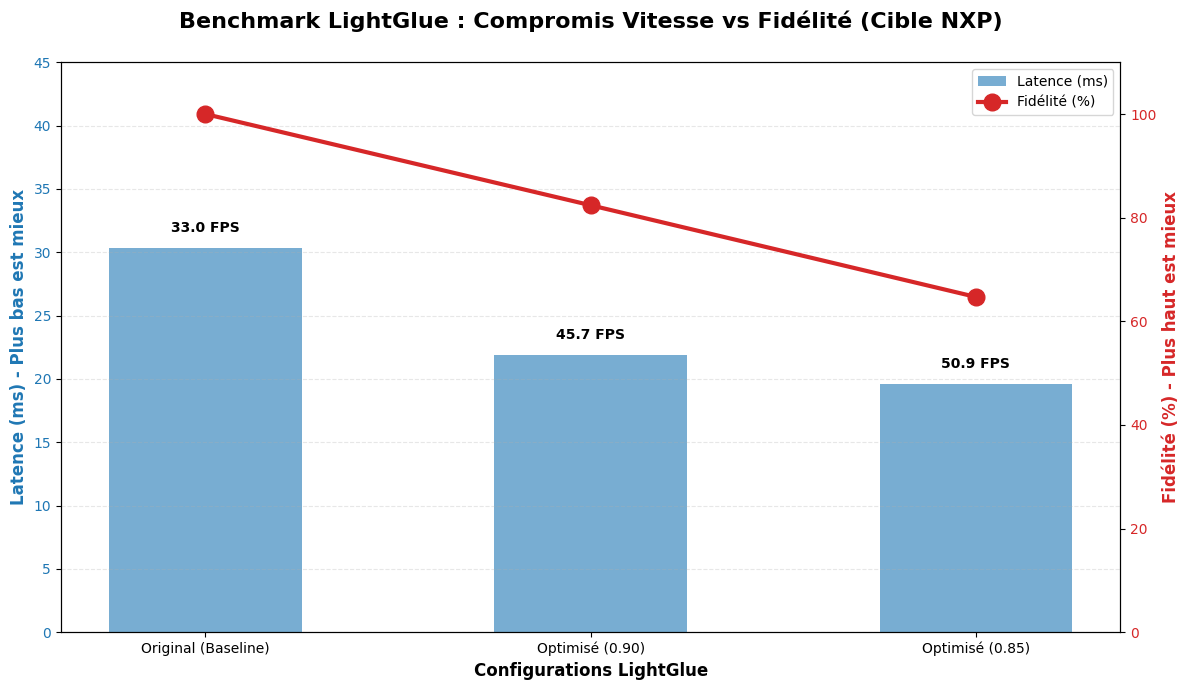

In [ ]:
import matplotlib.pyplot as plt

labels = ['Original (Baseline)', 'Optimisé (0.90)', 'Optimisé (0.85)']
latencies = [30.33, 21.88, 19.63]  # Temps en ms
fidelities = [100.0, 82.4, 64.7]   # Fidélité en %
fps = [33.0, 45.7, 50.9]           # FPS calculés

fig, ax1 = plt.subplots(figsize=(12, 7))

# Axe 1 : Latence
color_lat = 'tab:blue'
bars = ax1.bar(labels, latencies, color=color_lat, alpha=0.6, label='Latence (ms)', width=0.5)
ax1.set_xlabel('Configurations LightGlue', fontsize=12, fontweight='bold')
ax1.set_ylabel('Latence (ms) - Plus bas est mieux', color=color_lat, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_lat)
ax1.set_ylim(0, 45)

# Axe 2 : Fidélité
ax2 = ax1.twinx()
color_fid = 'tab:red'
ax2.plot(labels, fidelities, color=color_fid, marker='o', linewidth=3, markersize=12, label='Fidélité (%)')
ax2.set_ylabel('Fidélité (%) - Plus haut est mieux', color=color_fid, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_fid)
ax2.set_ylim(0, 110)
for i, bar in enumerate(bars):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{fps[i]:.1f} FPS', ha='center', va='bottom', fontweight='bold')

plt.title('Benchmark LightGlue : Compromis Vitesse vs Fidélité (Cible NXP)', fontsize=16, pad=25, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

lines, labels_leg = ax1.get_legend_handles_labels()
lines2, labels_leg2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels_leg + labels_leg2, loc='upper right')

plt.tight_layout()
plt.savefig('benchmark_lightglue_final.png')
plt.show()

In [ ]:
!pip install onnx onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.3 MB/s eta 0:00:00


In [ ]:
!pip install onnx onnxruntime-gpu onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 16.5 MB/s eta 0:00:00


In [ ]:
import torch
import time

class LightGluePureTensorWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, kpts0, desc0, size0, kpts1, desc1, size1):
        out = self.model({
            'image0': {'keypoints': kpts0, 'descriptors': desc0, 'image_size': size0},
            'image1': {'keypoints': kpts1, 'descriptors': desc1, 'image_size': size1}
        })

        m0 = out['matches0']
        # LightGlue utilise souvent 'matching_scores0' en interne
        s0 = out.get('matching_scores0', out.get('mscores0', torch.zeros_like(m0, dtype=torch.float32)))

        return m0, s0

matcher_raw = LightGlue(features='superpoint', flash=False, depth_confidence=-1).eval().to(device)
wrapper = LightGluePureTensorWrapper(matcher_raw).to(device)

kpts = torch.randn(1, 512, 2).to(device)
desc = torch.randn(1, 512, 256).to(device)
size = torch.tensor([[320, 240]], dtype=torch.float32).to(device)
args = (kpts, desc, size, kpts, desc, size)

#  Compilation JIT
print(" Compilation JIT en cours...")
try:
    with torch.no_grad():
        compiled_model = torch.jit.trace(wrapper, args)
    print(" SUCCÈS")

    # 5. Benchmark
    print(" Lancement du chrono")
    for _ in range(20): _ = compiled_model(*args) # Warmup

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(100):
        _ = compiled_model(*args)
    torch.cuda.synchronize()

    avg_time = (time.time() - start) / 100 * 1000

    print("-" * 50)
    print(f" TEMPS FINAL COMPILÉ (9 couches) : {avg_time:.2f} ms")
    print(f" PERFORMANCE                    : {1000/avg_time:.1f} FPS")
    print("-" * 50)

except Exception as e:
    print(f" Erreur lors de la compilation : {e}")
    import traceback
    traceback.print_exc()

    # 6. RÉSULTATS
    print("-" * 50)
    print(f" TEMPS COMPILÉ (9 couches) : {avg_time:.2f} ms")
    print(f" DÉBIT (THÉORIQUE)        : {1000/avg_time:.1f} FPS")
    print("-" * 50)

    # Analyse comparative
    print(f" Rappel : Ton record Python (avec Early Stopping) était de 11.03 ms.")
    if avg_time < 25:
        print(" Le modèle compilé est extrêmement performant malgré ses 9 couches complètes !")
    else:
        print(" Le gain de la compilation est présent, mais l'Early Stopping reste ton meilleur atout.")

⚡ Fusion de l'Early Stopping et de la Compilation (Scripting)...
❌ La fusion a échoué : 
cannot statically infer the expected size of a list in this context:
  File "/usr/local/lib/python3.12/dist-packages/lightglue/lightglue.py", line 115
    def forward(self, q, k, v, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        if q.shape[-2] == 0 or k.shape[-2] == 0:
            return q.new_zeros((*q.shape[:-1], v.shape[-1]))
                                ~~~~~~~~~~~~~ <--- HERE
        if self.enable_flash and q.device.type == "cuda":
            # use torch 2.0 scaled_dot_product_attention with flash

💡 Certains modèles complexes ne supportent le Scripting que via une réécriture partielle.
--------------------------------------------------
🏆 TEMPS COMPILÉ (9 couches) : 27.63 ms
⚡ DÉBIT (THÉORIQUE)        : 36.2 FPS
--------------------------------------------------
💡 Rappel : Ton record Python (avec Early Stopping) était de 11.03 ms.
📊 Le gain de la compilation est présent, ma